# Lab 5 – Spatial Filtering: Smoothing and Sharpening

## Task 1: Unsharp Masking

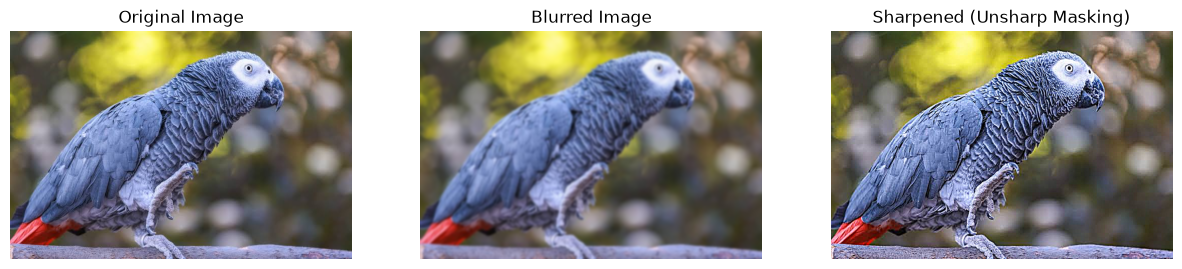

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('../images/parrot.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

sigma = 2       # Gaussian sigma
amount = 1.5    # parameter

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, (image, blurred, sharpened), ("Original Image", "Blurred Image", "Sharpened (Unsharp Masking)")):
    a.imshow(im); a.set_title(t); a.axis("off")
plt.show()

# Assessment
## Task 1: 7x7 box filter

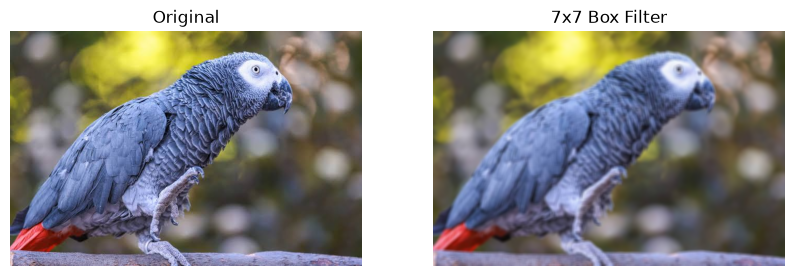

In [ ]:
 = cv2.cvtColor(cv2.imread('../images/parrot.jpg'), cv2.COLOR_BGR2RGB)

kernel = np.ones((7, 7), np.float32) / 49
box = cv2.filter2D(, -1, kernel)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for a, im, t in zip(ax, (, box), ("Original", "7x7 Box Filter")):
    a.imshow(np.clip(im, 0, 1) if im.dtype == np.float32 else im); a.set_title(t); a.axis("off")
plt.show()

## Task 2: 5x5 and 21x21 Gaussian filters

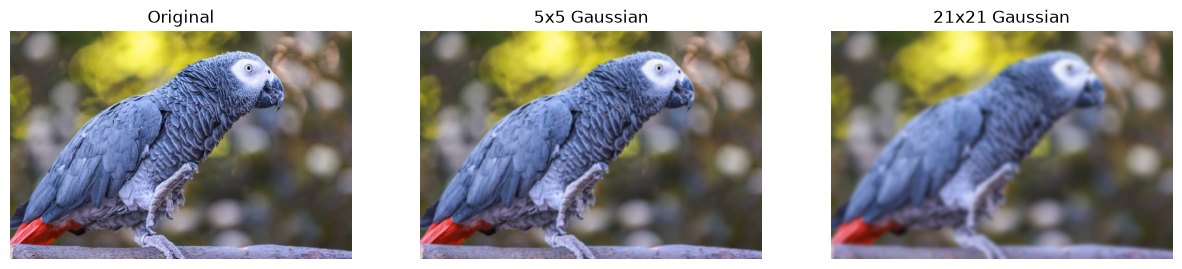

In [ ]:
g5 = cv2.GaussianBlur(, (5, 5), 0)
g21 = cv2.GaussianBlur(, (21, 21), 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, (, g5, g21), ("Original", "5x5 Gaussian", "21x21 Gaussian")):
    a.imshow(np.clip(im, 0, 1) if im.dtype == np.float32 else im); a.set_title(t); a.axis("off")
plt.show()

## Task 3: 3x3 Laplacian sharpening

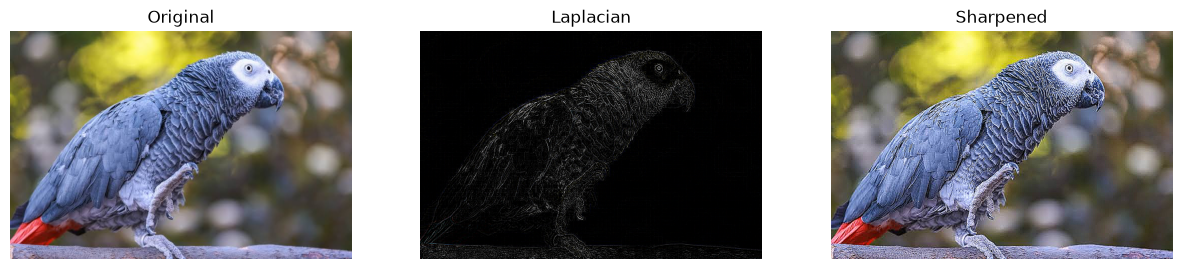

In [4]:
image = cv2.cvtColor(cv2.imread('../images/parrot.jpg'), cv2.COLOR_BGR2RGB)
image_float = image.astype(np.float32) / 255.0

laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=1)   # ksize=1 is the 3x3 Laplacian kernel
sharpened = np.clip(image_float - laplacian, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, (image_float, laplacian, sharpened), ("Original", "Laplacian", "Sharpened")):
    a.imshow(np.clip(im, 0, 1) if im.dtype == np.float32 else im); a.set_title(t); a.axis("off")
plt.show()